In [29]:
import glob

import astrodata
import gemini_instruments
from recipe_system.reduction.coreReduce import Reduce
from gempy.adlibrary import dataselect

In [30]:
from gempy.utils import logutils
logutils.config(file_name='gmos_data_reduction.log')

In [31]:
from recipe_system import cal_service

caldb = cal_service.set_local_database()
# caldb.init()

In [32]:
all_files = glob.glob('gmosimg_tutorial/playdata/example2/*.fits')
all_files.sort()

all_files

['gmosimg_tutorial/playdata/example2/N20220613S0138.fits',
 'gmosimg_tutorial/playdata/example2/N20220613S0139.fits',
 'gmosimg_tutorial/playdata/example2/N20220613S0140.fits',
 'gmosimg_tutorial/playdata/example2/N20220613S0141.fits',
 'gmosimg_tutorial/playdata/example2/N20220613S0142.fits',
 'gmosimg_tutorial/playdata/example2/N20220613S0180.fits',
 'gmosimg_tutorial/playdata/example2/N20220613S0181.fits',
 'gmosimg_tutorial/playdata/example2/N20220613S0182.fits',
 'gmosimg_tutorial/playdata/example2/N20220613S0183.fits',
 'gmosimg_tutorial/playdata/example2/N20220613S0184.fits',
 'gmosimg_tutorial/playdata/example2/N20220627S0115.fits',
 'gmosimg_tutorial/playdata/example2/N20220627S0116.fits',
 'gmosimg_tutorial/playdata/example2/N20220627S0117.fits',
 'gmosimg_tutorial/playdata/example2/N20220627S0118.fits',
 'gmosimg_tutorial/playdata/example2/N20220627S0119.fits',
 'gmosimg_tutorial/playdata/example2/N20220627S0222.fits',
 'gmosimg_tutorial/playdata/example2/N20220627S0223.fits

In [33]:
list_of_biastwi = dataselect.select_data(
    all_files,
    ['BIAS'],
    [],
    dataselect.expr_parser("ut_date=='2022-06-13'")
)

In [34]:
list_of_biassci = dataselect.select_data(
    all_files,
    ['BIAS'],
    [],
    dataselect.expr_parser("ut_date=='2022-06-27'")
)

In [35]:
list_of_flats = dataselect.select_data(
    all_files,
    ['FLAT'],
    [],
    dataselect.expr_parser('filter_name=="r"')
)

In [36]:
list_of_science = dataselect.select_data(
    all_files,
    [],
    ['CAL'],
    dataselect.expr_parser('(observation_class=="science" and filter_name=="r")')
)

In [37]:
for bpm in dataselect.select_data(all_files, ['BPM']):
    caldb.add_cal(bpm)

In [38]:
reduce_biastwi = Reduce()
reduce_biastwi.files.extend(list_of_biastwi)
reduce_biastwi.runr()

All submitted files appear valid:
gmosimg_tutorial/playdata/example2/N20220613S0180.fits ... gmosimg_tutorial/playdata/example2/N20220613S0184.fits, 5 files submitted.
RECIPE: makeProcessedBias
   PRIMITIVE: prepare
   ------------------
      PRIMITIVE: validateData
      -----------------------
      .
      PRIMITIVE: standardizeStructure
      -------------------------------
      .
      PRIMITIVE: standardizeHeaders
      -----------------------------
         PRIMITIVE: standardizeObservatoryHeaders
         ----------------------------------------
         Updating keywords that are common to all Gemini data
         .
         PRIMITIVE: standardizeInstrumentHeaders
         ---------------------------------------
         Updating keywords that are specific to GMOS
         Fixing headers for GMOS-N Hamamatsu data
         Updating keywords that are specific to GMOS
         Fixing headers for GMOS-N Hamamatsu data
         Updating keywords that are specific to GMOS
        

In [39]:
reduce_biassci = Reduce()
reduce_biassci.files.extend(list_of_biassci)
reduce_biassci.runr()

All submitted files appear valid:
gmosimg_tutorial/playdata/example2/N20220627S0222.fits ... gmosimg_tutorial/playdata/example2/N20220627S0226.fits, 5 files submitted.
RECIPE: makeProcessedBias
   PRIMITIVE: prepare
   ------------------
      PRIMITIVE: validateData
      -----------------------
      .
      PRIMITIVE: standardizeStructure
      -------------------------------
      .
      PRIMITIVE: standardizeHeaders
      -----------------------------
         PRIMITIVE: standardizeObservatoryHeaders
         ----------------------------------------
         Updating keywords that are common to all Gemini data
         .
         PRIMITIVE: standardizeInstrumentHeaders
         ---------------------------------------
         Updating keywords that are specific to GMOS
         Fixing headers for GMOS-N Hamamatsu data
         Updating keywords that are specific to GMOS
         Fixing headers for GMOS-N Hamamatsu data
         Updating keywords that are specific to GMOS
        

In [40]:
reduce_flats = Reduce()
reduce_flats.files.extend(list_of_flats)
reduce_flats.runr()

All submitted files appear valid:
gmosimg_tutorial/playdata/example2/N20220613S0138.fits ... gmosimg_tutorial/playdata/example2/N20220613S0142.fits, 5 files submitted.
RECIPE: makeProcessedFlat
   PRIMITIVE: prepare
   ------------------
      PRIMITIVE: validateData
      -----------------------
      .
      PRIMITIVE: standardizeStructure
      -------------------------------
      .
      PRIMITIVE: standardizeHeaders
      -----------------------------
         PRIMITIVE: standardizeObservatoryHeaders
         ----------------------------------------
         Updating keywords that are common to all Gemini data
         .
         PRIMITIVE: standardizeInstrumentHeaders
         ---------------------------------------
         Updating keywords that are specific to GMOS
         Fixing headers for GMOS-N Hamamatsu data
         Updating keywords that are specific to GMOS
         Fixing headers for GMOS-N Hamamatsu data
         Updating keywords that are specific to GMOS
        

In [41]:
reduce_science = Reduce()
reduce_science.files.extend(list_of_science)
reduce_science.recipename = 'reduceSeparateCCDs'
reduce_science.runr()

All submitted files appear valid:
gmosimg_tutorial/playdata/example2/N20220627S0115.fits ... gmosimg_tutorial/playdata/example2/N20220627S0119.fits, 5 files submitted.
RECIPE: reduceSeparateCCDs
   PRIMITIVE: prepare
   ------------------
      PRIMITIVE: validateData
      -----------------------
      .
      PRIMITIVE: standardizeStructure
      -------------------------------
      .
      PRIMITIVE: standardizeHeaders
      -----------------------------
         PRIMITIVE: standardizeObservatoryHeaders
         ----------------------------------------
         Updating keywords that are common to all Gemini data
         .
         PRIMITIVE: standardizeInstrumentHeaders
         ---------------------------------------
         Updating keywords that are specific to GMOS
         Fixing headers for GMOS-N Hamamatsu data
         Updating keywords that are specific to GMOS
         Fixing headers for GMOS-N Hamamatsu data
         Updating keywords that are specific to GMOS
       

Filename: N20220627S0115_image.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     249   ()      
  1  SCI           1 ImageHDU       258   (1159, 2236)   float32   
  2  VAR           1 ImageHDU       258   (1159, 2236)   float32   
  3  DQ            1 ImageHDU       258   (1159, 2236)   int16 (rescales to uint16)   
  4  OBJMASK       1 ImageHDU       258   (1159, 2236)   uint8   
  5  OBJCAT        1 BinTableHDU    170   434R x 43C   [J, E, E, D, D, D, D, D, D, D, D, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, J, I, J, J, E, J, E, E, E, E]   
  6  SCI           2 ImageHDU       150   (1159, 2236)   float32   
  7  VAR           2 ImageHDU       150   (1159, 2236)   float32   
  8  DQ            2 ImageHDU       150   (1159, 2236)   int16 (rescales to uint16)   
  9  OBJMASK       2 ImageHDU       150   (1159, 2236)   uint8   
 10  OBJCAT        2 BinTableHDU    170   230R x 43C   [J, E, E, D, D, D, D, D, D, D,

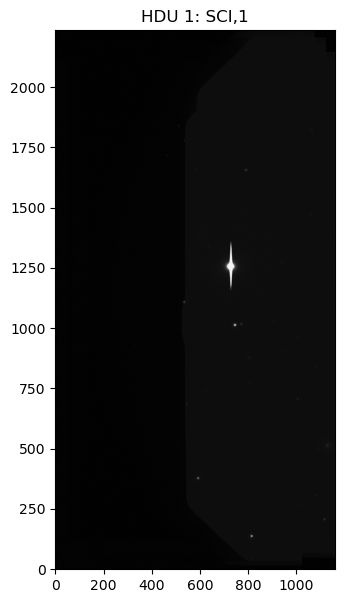

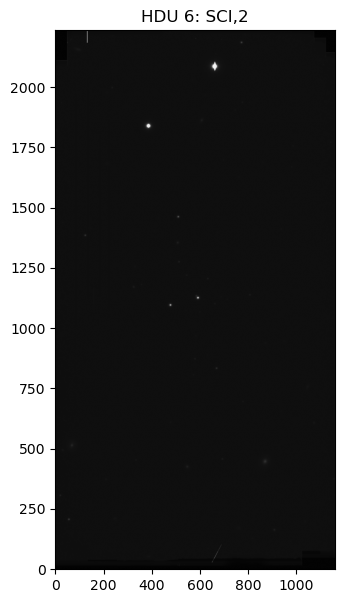

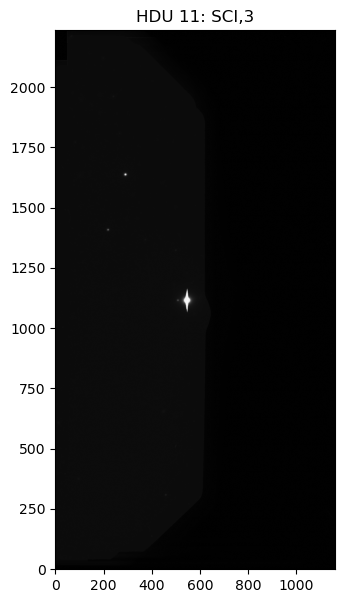

In [46]:
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.visualization import ZScaleInterval

hdul = fits.open("N20220627S0115_image.fits")

hdul.info()

for ext in [1, 6, 11]:

    data = hdul[ext].data

    plt.figure(figsize=(7,7))

    plt.imshow(data, origin="lower", cmap="gray")

    plt.title(f"HDU {ext}: {hdul[ext].name},{hdul[ext].ver}")

    plt.show()